#Importing libraries

In [ ]:
!pip install rdkit
!pip install mordred[full]

In [ ]:
!pip install tqdm

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import requests
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.ML.Descriptors import MoleculeDescriptors
from tqdm import tqdm
from rdkit.Chem import AllChem
import requests
from pathlib import Path
import time
import pandas as pd

# Downloading target data from databases

## Chembl

In [ ]:
# Downloading IC50 data for small molecules
def download_chembl_data(target_chembl_id: str, output_path: str | Path):

    # Request
    BASE_URL = "https://www.ebi.ac.uk/chembl/api/data/activity.json"
    PARAMS = {
        "target_chembl_id": target_chembl_id,
        "standard_type": "IC50",
        "limit": 1000
    }

    all_activities = []
    page = 0

    # Loading cycle in batches of limit lines
    while True:
        PARAMS["offset"] = PARAMS["limit"] * page

        try:
            response = requests.get(BASE_URL, params=PARAMS, timeout=30)
            response.raise_for_status()
        except requests.exceptions.RequestException as e:
            if isinstance(e, requests.exceptions.HTTPError) and e.response.status_code == 429:
                time.sleep(10)
                continue
            else:
                print(f"Network error when requesting: {e}")
                break

        data = response.json()
        activities = data.get("activities")

        # If the page is empty, it means everything is loaded
        if not activities:
            break

        all_activities.extend(activities)
        page += 1
        time.sleep(10) # A small delay between requests

    # Nothing was downloaded
    if not all_activities:
        return

    # Saving
    df_chembl_raw = pd.DataFrame(all_activities)
    df_chembl_raw.to_csv(output_path, index=False)

In [ ]:
download_chembl_data("CHEMBL203", 'chembl_raw.csv')

In [ ]:
df_chembl_raw = pd.read_csv('chembl_raw.csv')
df_chembl_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25758 entries, 0 to 25757
Data columns (total 46 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   action_type                3397 non-null   object 
 1   activity_comment           8665 non-null   object 
 2   activity_id                25758 non-null  int64  
 3   activity_properties        25758 non-null  object 
 4   assay_chembl_id            25758 non-null  object 
 5   assay_description          25758 non-null  object 
 6   assay_type                 25758 non-null  object 
 7   assay_variant_accession    3811 non-null   object 
 8   assay_variant_mutation     4526 non-null   object 
 9   bao_endpoint               25758 non-null  object 
 10  bao_format                 25758 non-null  object 
 11  bao_label                  25758 non-null  object 
 12  canonical_smiles           25711 non-null  object 
 13  data_validity_comment      503 non-null    obj

/tmp/ipython-input-75687159.py:1: DtypeWarning: Columns (30,39) have mixed types. Specify dtype option on import or set low_memory=False.
  df_chembl_raw = pd.read_csv('chembl_raw.csv')


In [ ]:
df_chembl_raw = df_chembl_raw[["canonical_smiles", "standard_value"]] \
  .rename(columns={
      "canonical_smiles": "smiles",
      "standard_value": "label"
  })

In [ ]:
df_chembl_raw.head()

,smiles,label
0,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...,41.0
1,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...,300.0
2,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...,7820.0
3,Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...,170.0
4,Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...,40.0


## Pubchem

In [ ]:
import requests
from pathlib import Path
import time
import pandas as pd

In [ ]:
def download_pubchem_data(target_accession: str, output_path: str | Path):

    try:
        # Uploading all bioassays by target
        bioassay_url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/assay/target/accession/{target_accession}/concise/json"
        response = requests.get(bioassay_url, timeout=60)
        response.raise_for_status()
        concise_data = response.json()

        df_bioassay = pd.DataFrame(
            data=[row["Cell"] for row in concise_data["Table"]["Row"]],
            columns=concise_data["Table"]["Columns"]["Column"]
        )

        # Download SMILES
        cids_string = ",".join(df_bioassay["CID"].astype(str).unique())
        smiles_url = "https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/cid/property/SMILES/json"
        post_data = {"cid": cids_string}

        response = requests.post(smiles_url, data=post_data, timeout=120)
        response.raise_for_status()
        smiles_data = response.json()

        df_smiles = pd.DataFrame(smiles_data["PropertyTable"]["Properties"])

        # Combining data
        df_bioassay["CID"] = pd.to_numeric(df_bioassay["CID"], errors="coerce")
        df_bioassay.dropna(subset=["CID"], inplace=True)
        df_bioassay["CID"] = df_bioassay["CID"].astype(int)

        df_merged = pd.merge(df_bioassay, df_smiles, how='left', on='CID')
        df_merged.to_csv(output_path, index=False)

    except requests.exceptions.RequestException as e:
        print(f"X Error loading data from PubChem: {e}")
    except KeyError as e:
        print(f"X Error: Invalid response format from the API. The key was not found: {e}")

In [ ]:
download_pubchem_data("P00533",'pub.csv')

In [ ]:
df_pubchem_raw = pd.read_csv('pub.csv')
df_pubchem_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58674 entries, 0 to 58673
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   AID                  58674 non-null  int64  
 1   SID                  58674 non-null  int64  
 2   CID                  58674 non-null  int64  
 3   Activity Outcome     58674 non-null  object 
 4   Target Accession     58673 non-null  object 
 5   Target GeneID        9866 non-null   float64
 6   Activity Value [uM]  41548 non-null  float64
 7   Activity Name        40983 non-null  object 
 8   Assay Name           58674 non-null  object 
 9   Assay Type           58674 non-null  object 
 10  PubMed ID            30457 non-null  float64
 11  RNAi                 0 non-null      float64
 12  SMILES               58674 non-null  object 
dtypes: float64(4), int64(3), object(6)
memory usage: 5.8+ MB


In [ ]:
df_pubchem_raw = df_pubchem_raw[df_pubchem_raw["Activity Name"] == "IC50"]
df_pubchem_raw = df_pubchem_raw[df_pubchem_raw["Activity Outcome"] == "Active"]
df_pubchem_raw = df_pubchem_raw[df_pubchem_raw["Target Accession"] == "P00533"]

In [ ]:
df_pubchem_raw = df_pubchem_raw[["SMILES", "Activity Value [uM]"]] \
  .rename(columns={
      "Activity Value [uM]": "label",
      "SMILES": "smiles"
  })

In [ ]:
df_pubchem_raw.head()

,smiles,label
3394,CC1=C(NC(=C1)C(=O)N2CCOCC2)/C=C\3/C4=C(NC3=O)N...,4.32
3395,CCN(CC)CCNC(=O)C1=CC(=C(N1)/C=C\2/C3=C(NC2=O)N...,1.29
3396,CCN1CCN(CC1)C(=O)C2=CC(=C(N2)/C=C\3/C4=C(NC3=O...,7.50
3397,CC1=C(NC(=C1)C(=O)NCCN2CCOCC2)/C=C\3/C4=C(NC3=...,1.95
3398,CC1=C(NC(=C1)C(=O)NCCN2CCOCC2)/C=C\3/C4=C(NC3=...,0.62


# Combining data

In [ ]:
df_combined_raw = pd.concat(
    (
        df_chembl_raw,
        df_pubchem_raw,
    ),
    axis=0
)

In [ ]:
print(
    f"""pubchem: {len(df_pubchem_raw)}
chembl: {len(df_chembl_raw)}
combined: {len(df_combined_raw)}
    """
)

pubchem: 22649
chembl: 25758
combined: 48407
    


In [ ]:
df_combined_raw.head()

,smiles,label
0,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...,41.0
1,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...,300.0
2,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...,7820.0
3,Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...,170.0
4,Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...,40.0


In [ ]:
df_combined_raw.isna().sum()

,0
smiles,47
label,1395


# Dataset Preprocessing



In [ ]:
# Selecting the right columns and clearing the data
processed_df = df_combined_raw.copy()
print(len(processed_df))

48407


In [ ]:
# Deleting missing values
processed_df = processed_df.dropna()
print(len(processed_df))

46993


In [ ]:
# Conversion to numeric format and filtering of incorrect values
processed_df['label'] = pd.to_numeric(processed_df['label'], errors='coerce')
processed_df = processed_df.dropna(subset=['label'])
processed_df = processed_df[processed_df['label'] > 0]
print(len(processed_df))

46992


In [ ]:
# Convert IC50 to pIC50
processed_df['label'] = 9-np.log10(processed_df['label'])

In [ ]:
processed_df.head()

,smiles,label
0,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...,7.387216
1,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...,6.522879
2,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...,5.106793
3,Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...,6.769551
4,Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...,7.397940


In [ ]:
# Removing duplicates by SMILES
processed_df = processed_df.drop_duplicates(subset=['smiles'])
print(len(processed_df))

25478


# Descriptors

In [ ]:
desc_names = [d[0] for d in Descriptors._descList]
calc = MoleculeDescriptors.MolecularDescriptorCalculator(desc_names)
desc_data = []
for mol_repr in processed_df['smiles']:
    mol = None
    # We try it first as molblock, then as SMILES
    try:
        mol = Chem.MolFromMolBlock(mol_repr, sanitize=True)
    except Exception:
        mol = None
    if mol is None:
        try:
            mol = Chem.MolFromSmiles(mol_repr)
        except Exception:
            mol = None
  # If the molecule is invalid, the descriptors will be NaN
    if mol is not None:
        vals = calc.CalcDescriptors(mol)
        desc_data.append(vals)
    else:
        desc_data.append([np.nan]*len(desc_names))
df_desc = pd.DataFrame(desc_data, columns=desc_names)
df_rdkit = processed_df.reset_index(drop=True).join(df_desc)
print(f'Rows after calculating the descriptors {len(df_rdkit)}:')
print(f'Columns after RDKit descriptors ({len(df_rdkit.columns)}):')
print(list(df_rdkit.columns))

[00:41:52] Conflicting single bond directions around double bond at index 13.
[00:41:52]   BondStereo set to STEREONONE and single bond directions set to NONE.
[00:41:52] Conflicting single bond directions around double bond at index 13.
[00:41:52]   BondStereo set to STEREONONE and single bond directions set to NONE.


После расчета дескрипторов: 25478 строк
Колонки после RDKit-дескрипторов (219):
['smiles', 'label', 'MaxAbsEStateIndex', 'MaxEStateIndex', 'MinAbsEStateIndex', 'MinEStateIndex', 'qed', 'SPS', 'MolWt', 'HeavyAtomMolWt', 'ExactMolWt', 'NumValenceElectrons', 'NumRadicalElectrons', 'MaxPartialCharge', 'MinPartialCharge', 'MaxAbsPartialCharge', 'MinAbsPartialCharge', 'FpDensityMorgan1', 'FpDensityMorgan2', 'FpDensityMorgan3', 'BCUT2D_MWHI', 'BCUT2D_MWLOW', 'BCUT2D_CHGHI', 'BCUT2D_CHGLO', 'BCUT2D_LOGPHI', 'BCUT2D_LOGPLOW', 'BCUT2D_MRHI', 'BCUT2D_MRLOW', 'AvgIpc', 'BalabanJ', 'BertzCT', 'Chi0', 'Chi0n', 'Chi0v', 'Chi1', 'Chi1n', 'Chi1v', 'Chi2n', 'Chi2v', 'Chi3n', 'Chi3v', 'Chi4n', 'Chi4v', 'HallKierAlpha', 'Ipc', 'Kappa1', 'Kappa2', 'Kappa3', 'LabuteASA', 'PEOE_VSA1', 'PEOE_VSA10', 'PEOE_VSA11', 'PEOE_VSA12', 'PEOE_VSA13', 'PEOE_VSA14', 'PEOE_VSA2', 'PEOE_VSA3', 'PEOE_VSA4', 'PEOE_VSA5', 'PEOE_VSA6', 'PEOE_VSA7', 'PEOE_VSA8', 'PEOE_VSA9', 'SMR_VSA1', 'SMR_VSA10', 'SMR_VSA2', 'SMR_VSA3', 'SMR

In [ ]:
# Creating a dataframe with only descriptors without information about the activity (pValue) and the structure of the molecule (smiles)
df_descriptors_only = df_rdkit.drop(columns=['smiles', 'label'], errors='ignore').copy()
df_descriptors_only.head()

,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,13.399867,13.399867,0.006339,-0.509118,0.583357,14.370370,383.814,368.694,383.094916,136,...,0,0,0,0,0,0,0,0,0,0
1,13.542332,13.542332,0.041534,-0.539617,0.489619,16.500000,482.903,462.743,482.126944,174,...,0,0,0,0,0,0,0,0,0,0
2,4.485145,4.485145,0.423142,0.423142,0.391062,11.035714,369.432,350.280,369.170194,138,...,0,0,0,0,0,0,0,0,0,0
3,11.466694,11.466694,0.035411,-1.026115,0.804599,9.095238,283.287,270.183,283.095691,106,...,0,0,0,0,0,0,0,0,0,0
4,10.103372,10.103372,0.168958,-0.983264,0.650834,10.333333,164.160,156.096,164.047344,62,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# Removing non-numeric characters for a dataframe consisting of only descriptors
df_descriptors_only = df_descriptors_only.select_dtypes(include=[np.number])

print(f'The number of rows after deleting non-numeric characters: {df_descriptors_only.shape[0]}')
print(f'The number of columns after deleting non-numeric features: {df_descriptors_only.shape[1]}')

The number of rows after deleting non-numeric characters: 25478
The number of columns after deleting non-numeric features: 143


In [ ]:
# Removing features where there is at least one inf, -inf, NaN, or extremum in the dataframe from the same descriptors
extreme = 1e6
df_descriptors_only = df_descriptors_only.loc[:, (np.isfinite(df_descriptors_only).all(axis=0)) &
                                                (df_descriptors_only.abs() < extreme).all(axis=0)]

In [ ]:
# Remove the constant signs, output the results
selector = VarianceThreshold(threshold=0.01)
X_var = selector.fit_transform(df_descriptors_only)
selected_cols = df_descriptors_only.columns[selector.get_support()]
df_descriptors_only = pd.DataFrame(X_var, columns=selected_cols, index=df_descriptors_only.index)

print(f'Number of lines after removing constants: {df_descriptors_only.shape[0]}')
print(f'Number of columns after removing constants: {df_descriptors_only.shape[1]}')

Number of lines after removing constants: 25478
Number of columns after removing constants: 143


In [ ]:
# We remove highly correlated features, output the results
corr = df_descriptors_only.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]
df_descriptors_only = df_descriptors_only.drop(columns=to_drop)

print(f'The number of rows after deletion is high: {df_descriptors_only.shape[0]}')
print(f'The number of columns after deletion is high: {df_descriptors_only.shape[1]}')

The number of rows after deletion is high: 25478
The number of columns after deletion is high: 143


In [ ]:
df_final = pd.concat(
    (df_rdkit[["smiles", "label"]], df_descriptors_only),
    axis=1
)

df_final.head()

,smiles,label,MaxAbsEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,FpDensityMorgan1,FpDensityMorgan2,...,fr_priamide,fr_pyridine,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_thiazole,fr_thiophene,fr_unbrch_alkane,fr_urea
0,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...,7.387216,13.399867,0.006339,-0.509118,0.583357,14.370370,383.814,1.222222,2.037037,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...,6.769551,13.542332,0.041534,-0.539617,0.489619,16.500000,482.903,1.264706,2.058824,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,CN(c1ccccc1)c1ncnc2ccc(N/N=N/Cc3ccccn3)cc12,5.031517,4.485145,0.423142,0.423142,0.391062,11.035714,369.432,0.928571,1.785714,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,CC(=C(C#N)C#N)c1ccc(NC(=O)CCC(=O)O)cc1,3.301030,11.466694,0.035411,-1.026115,0.804599,9.095238,283.287,1.142857,1.714286,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,O=C(O)/C=C/c1ccc(O)cc1,2.522879,10.103372,0.168958,-0.983264,0.650834,10.333333,164.160,1.250000,1.833333,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


#Visualization

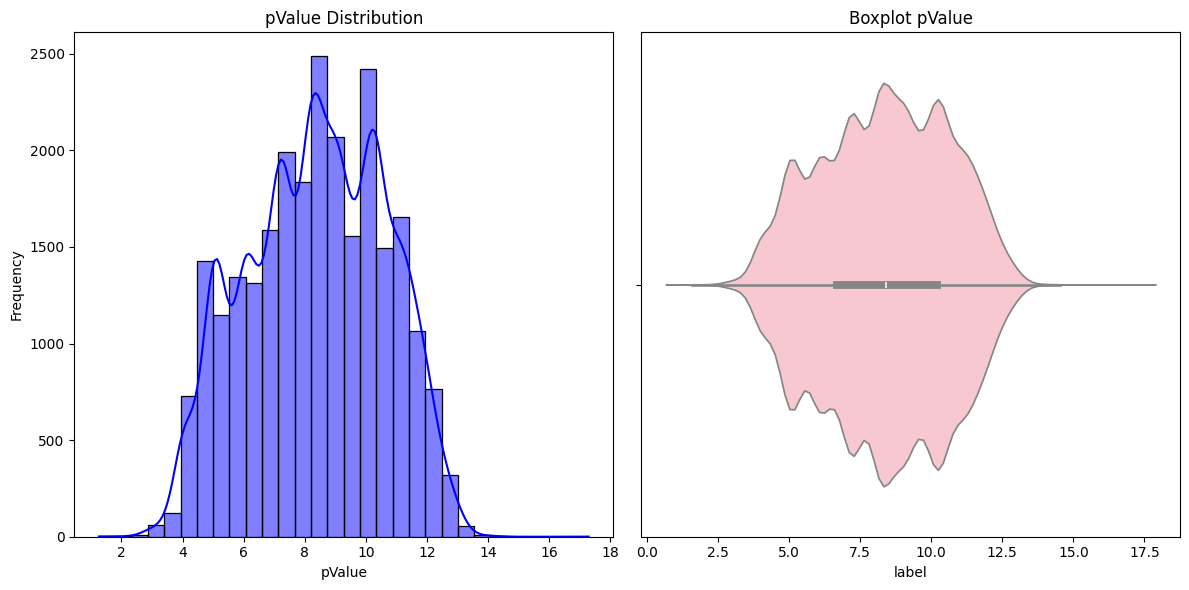

In [98]:
# pValue target variable distribution analysis
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.histplot(df_final['label'], bins=30, kde=True, color='blue')
plt.title('pValue Distribution')
plt.xlabel('pValue')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.violinplot(df_final,x=df_final['label'], color='pink')
plt.title('Boxplot pValue')
plt.tight_layout()
plt.show()

#Conservation

In [ ]:
df_final.to_csv("dataset.csv")